In [1]:
import csv
import re
import os
import pandas as pd
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import (
    AutoTokenizer,
    AutoModel,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
)
from datasets import Dataset, DatasetDict


/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
#%% Load and prepare data
dataset_raw = pd.read_csv('Data/Product_Normalization_GRI.csv')
normalized_product_attributes = pd.read_excel('Data/Normalized_product_attribute_name.xlsx', sheet_name='Normalized Product Attributes')


In [3]:
#%% Loading Preprocessed (Expanded) Dataset
dataset_raw_expanded = pd.read_csv('Data/Product_Normalization_GRI_Expanded.csv')

In [4]:
descriptions = dataset_raw_expanded['Room Description Expanded'].unique()

In [11]:
len(dataset_raw_expanded)

31237

In [7]:
dataset_raw_expanded = dataset_raw_expanded.drop_duplicates(subset=['Room Description Expanded'])


In [ ]:
dataset_raw_expanded[dataset_raw_expanded['Guest Room Info'] == 'Bungalow']

,Unnamed: 0,Room Description,Guest Room Info,Room Description Expanded
13000,13000,TRIPADVISOR PLUS|SINGLE STORY BUNGALOW APPROXI...,Bungalow,TRIPADVISOR PLUS|SINGLE STORY BUNGALOW APPROXI...
13001,13001,OUR BEST AVAILABLE RATE|2 BDRM BUNGALOW HOME -...,Bungalow,OUR BEST AVAILABLE RATE|2 BDRM BUNGALOW HOME -...
13006,13006,SPA REJUVENATION PACKAGE|2 BDRM BUNGALOW HOME ...,Bungalow,SPA REJUVENATION PACKAGE|2 BDRM BUNGALOW HOME ...
13008,13008,TRIPADVISOR PLUS|SINGLE STORY BUNGALOW SUITE A...,Bungalow,TRIPADVISOR PLUS|SINGLE STORY BUNGALOW SUITE A...
13009,13009,TRIPADVISOR PLUS|SINGLE STORY BUNGALOW SUITE A...,Bungalow,TRIPADVISOR PLUS|SINGLE STORY BUNGALOW SUITE A...
...,...,...,...,...
13995,13995,ULTIMATE STAYCATION|BEVERLY HILLS BUNGALOW SUI...,Bungalow,ULTIMATE STAYCATION|BEVERLY HILLS BUNGALOW SUI...
13996,13996,SIGNATURE TRAVEL NET|END OF PONTOON OVERWATER ...,Bungalow,SIGNATURE TRAVEL NET|END OF PONTOON OVERWATER ...
13997,13997,BEST AVAILABLE RATE|533 SQ. FT. VINEYARD MURPH...,Bungalow,BEST AVAILABLE RATE|533 SQ. FT. VINEYARD MURPH...
13998,13998,AMEX GBT GHP RATE|OCEAN COASTAL BUNGALOW SUITE...,Bungalow,AMEX GBT GHP RATE|OCEAN COASTAL BUNGALOW SUITE...


In [10]:
dataset_raw_expanded[dataset_raw_expanded.isnull().any(axis=1)]
#dataset_raw_expanded = dataset_raw_expanded.fillna('Bungalow')

,Unnamed: 0,Room Description,Guest Room Info,Room Description Expanded


In [12]:
normalized_product_attributes

,BedType,OTA TYPE = BED,Unnamed: 2,RoomType,OTA TYPE = GRI,Unnamed: 5,Rateplan Incl/Value-adds,OTA TYPE = HAC,Unnamed: 8,Room Amenities,OTA TYPE = RMA,Unnamed: 11,Mealplan,OTA TYPE = MPT,Unnamed: 14,RoomView,OTA TYPE = RVT,Unnamed: 17,Taxes & Fees,OTA TYPE = FTT
0,Double/Full Bed,1.0,NaN,Accessible Room,1.0,NaN,Piano,0,NaN,Adjoining rooms,1.0,NaN,All Inclusive,1.0,NaN,Airport view,1.0,NaN,Bed tax,1.0
1,Futon Bed,2.0,NaN,Suite,3.0,NaN,24-hour front desk,1,NaN,Air conditioning,2.0,NaN,Full Board or American,2.0,NaN,Bay view,2.0,NaN,City hotel fee,2.0
2,King Bed,3.0,NaN,Executive/Club Suite,6.0,NaN,24-hour room service,2,NaN,Alarm clock,3.0,NaN,Buffet Breakfast,4.0,NaN,City view,3.0,NaN,PropertyFee,2.0
3,Murphy Bed,4.0,NaN,Double Room,10.0,NaN,24-hour security,3,NaN,All news channel,4.0,NaN,Continental Breakfast,6.0,NaN,Courtyard view,4.0,NaN,City tax,3.0
4,Queen Bed,5.0,NaN,King Bedroom,11.0,NaN,adjoining rooms,4,NaN,radio,5.0,NaN,Family Plan,9.0,NaN,Golf View,5.0,NaN,Municipal Tax,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,NaN,NaN,NaN,NaN,NaN,NaN,Train station shuttle services,2030,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
378,NaN,NaN,NaN,NaN,NaN,NaN,Electric car charging stations,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
379,NaN,NaN,NaN,NaN,NaN,NaN,Golf clubs (equipments),2032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
380,NaN,NaN,NaN,NaN,NaN,NaN,Beach club,2033,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Get room types
room_types = normalized_product_attributes['RoomType'].dropna().unique()
room_types_list = room_types.tolist()

bed_types = normalized_product_attributes['BedType'].dropna().unique()
bed_types_list = bed_types.tolist()

room_amenities = normalized_product_attributes['Room Amenities'].dropna().unique()
room_amenities_list = room_amenities.tolist()

rateplan_types = normalized_product_attributes['Rateplan Incl/Value-adds'].dropna().unique()
rateplan_types_list = rateplan_types.tolist()

meal_plan = normalized_product_attributes['Mealplan'].dropna().unique()
meal_plan_list = meal_plan.tolist()

room_view = normalized_product_attributes['RoomView'].dropna().unique()
room_view_list = room_view.tolist()

taxes_view = normalized_product_attributes['Taxes & Fees'].dropna().unique()
taxes_view_list = taxes_view.tolist()



In [ ]:
room_types_stripped_list = []
for item in room_types_list:
    room_types_stripped_list.append(item.strip())

bed_types_stripped_list = []
for item in bed_types_list:
    bed_types_stripped_list.append(item.strip())

room_amenities_stripped_list = []
for item in room_amenities_list:
    room_amenities_stripped_list.append(item.strip())

In [18]:
dataset_raw_expanded['Room Description Expanded']

0        FLEXIBLE RATE|2QUEEN HEARING ACCESSIBLE STUDIO...
1        2X POINTS PACKAGE|2QUEEN HEARING ACCESSIBLE ST...
2        PARK AND STAY AAA|2QUEEN HEARING ACCESSIBLE ST...
3        PARK AND STAY AARP|2QUEEN HEARING ACCESSIBLE S...
4        PARK AND GO|2QUEEN HEARING ACCESSIBLE STUDIO S...
                               ...                        
34990    BEST FLEXIBLE RATE|PREMIUM OCEAN VIEW ROOM WHE...
34991    1000 BONUS POINTS NT INCLUDES|ROOM AND 1000 RE...
34992    BEST FLEXIBLE RATE|HOLIDAY INN EXPRESS ROOM WH...
34993    GREATRATE DISCOUNTED STAYS. 2|RUN OF HOUSE STA...
34995    CWT INCLUDES WIFI USE OF|FITNESS AND WELLNESS ...
Name: Room Description Expanded, Length: 31237, dtype: object

In [15]:
from gensim import corpora, models
import gensim

In [27]:
def apply_topic_modeling(descriptions, num_topics=50):
    """
    Apply LDA topic modeling on full descriptions
    """
    # 1. Preprocess
    texts = [
        gensim.utils.simple_preprocess(desc, deacc=True)
        for desc in descriptions
    ]
    
    # 2. Create dictionary and corpus
    dictionary = corpora.Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]
    
    # 3. Train LDA model
    lda_model = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        update_every=1,
        passes=10,
        alpha='auto',
        per_word_topics=True
    )
    
    # 4. Get topics
    topics = lda_model.print_topics(num_words=10)
    
    return lda_model, dictionary, corpus, topics

In [ ]:
### n = 50
# Apply and analyze
lda_model, dictionary, corpus, topics = apply_topic_modeling(
dataset_raw_expanded['Room Description Expanded'],
num_topics=50  # Start with 50 topics
)

# Print topics
for idx, topic in topics:
    print(f"\nTopic {idx}:")
    print(topic)


Topic 38:
0.421*"views" + 0.100*"pref" + 0.074*"consortia" + 0.066*"has" + 0.049*"sale" + 0.043*"designed" + 0.041*"great" + 0.022*"upper" + 0.019*"lv" + 0.018*"bathrms"

Topic 16:
0.270*"aaa" + 0.093*"required" + 0.080*"rate" + 0.079*"caa" + 0.074*"membership" + 0.065*"card" + 0.047*"auto" + 0.045*"american" + 0.043*"confiden" + 0.043*"king"

Topic 13:
0.205*"discount" + 0.128*"senior" + 0.075*"aarp" + 0.062*"marriott" + 0.052*"side" + 0.052*"disc" + 0.050*"fl" + 0.038*"and" + 0.033*"mt" + 0.030*"id"

Topic 35:
0.211*"usd" + 0.147*"courtyard" + 0.116*"chg" + 0.086*"rsrt" + 0.074*"rc" + 0.050*"kng" + 0.044*"suites" + 0.037*"any" + 0.036*"consecutive" + 0.035*"lux"

Topic 37:
0.094*"tv" + 0.087*"flat" + 0.073*"air" + 0.065*"screen" + 0.059*"room" + 0.040*"free" + 0.033*"wireless" + 0.032*"conditioning" + 0.029*"in" + 0.027*"cable"

Topic 49:
0.119*"rate" + 0.110*"see" + 0.100*"details" + 0.074*"prepay" + 0.058*"refundable" + 0.055*"non" + 0.048*"stay" + 0.043*"to" + 0.038*"room" + 0.03

In [34]:
# Or save as CSV for better structure
import pandas as pd
all_topics = lda_model.show_topics(num_topics=50, num_words=10)
topics_df = pd.DataFrame([
    {
        'Topic_ID': idx,
        'Top_Words': topic
    } for idx, topic in all_topics
])

topics_df.to_csv('topic_analysis_50.csv', index=False)

In [36]:
import xlsxwriter

def format_topics(lda_model, num_topics=50, num_words=10):
    topics_df = pd.DataFrame()
    
    for idx in range(num_topics):
        words = []
        weights = []
        
        # Get topic words and their weights
        for word, weight in lda_model.show_topic(idx, num_words):
            words.append(word)
            weights.append(round(weight, 3))
        
        # Create readable format
        topic_dict = {
            'Topic': f'Topic {idx}',
            'Words': ', '.join(words),
            'Weights': ', '.join([f'{w:.3f}' for w in weights]),
            'Top 3 Words': ', '.join(words[:3]),
            'Interpretation': f'Topic about: {", ".join(words[:3])}'  # Simple interpretation
        }
        
        topics_df = pd.concat([topics_df, pd.DataFrame([topic_dict])], ignore_index=True)
    
    return topics_df

# Create readable topics
readable_topics = format_topics(lda_model)

# Save to Excel with formatting
with pd.ExcelWriter('topic_analysis_50.xlsx', engine='xlsxwriter') as writer:
    readable_topics.to_excel(writer, index=False, sheet_name='Topics')
    
    # Auto-adjust column widths
    worksheet = writer.sheets['Topics']
    for idx, col in enumerate(readable_topics.columns):
        max_length = max(readable_topics[col].astype(str).apply(len).max(), len(col))
        worksheet.set_column(idx, idx, max_length + 2)

print("Sample of readable format:")
print(readable_topics[['Topic', 'Top 3 Words', 'Interpretation']].head())

Sample of readable format:
     Topic            Top 3 Words                      Interpretation
0  Topic 0         in, shower, th         Topic about: in, shower, th
1  Topic 1  premium, travel, wifi  Topic about: premium, travel, wifi
2  Topic 2            sq, ft, bed            Topic about: sq, ft, bed
3  Topic 3   executive, inc, with   Topic about: executive, inc, with
4  Topic 4          or, twin, sqm          Topic about: or, twin, sqm


In [37]:
### n = 240
# Apply and analyze
lda_model, dictionary, corpus, topics = apply_topic_modeling(
dataset_raw_expanded['Room Description Expanded'],
num_topics=240
)

# Print topics
for idx, topic in topics:
    print(f"\nTopic {idx}:")
    print(topic)


Topic 27:
0.000*"oft" + 0.000*"cup" + 0.000*"tdg" + 0.000*"rainshwer" + 0.000*"paytv" + 0.000*"racing" + 0.000*"royalty" + 0.000*"loveseat" + 0.000*"fantastic" + 0.000*"players"

Topic 178:
0.000*"oft" + 0.000*"cup" + 0.000*"tdg" + 0.000*"rainshwer" + 0.000*"paytv" + 0.000*"racing" + 0.000*"royalty" + 0.000*"loveseat" + 0.000*"fantastic" + 0.000*"players"

Topic 168:
0.000*"oft" + 0.000*"cup" + 0.000*"tdg" + 0.000*"rainshwer" + 0.000*"paytv" + 0.000*"racing" + 0.000*"royalty" + 0.000*"loveseat" + 0.000*"fantastic" + 0.000*"players"

Topic 203:
0.000*"oft" + 0.000*"cup" + 0.000*"tdg" + 0.000*"rainshwer" + 0.000*"paytv" + 0.000*"racing" + 0.000*"royalty" + 0.000*"loveseat" + 0.000*"fantastic" + 0.000*"players"

Topic 28:
0.000*"oft" + 0.000*"cup" + 0.000*"tdg" + 0.000*"rainshwer" + 0.000*"paytv" + 0.000*"racing" + 0.000*"royalty" + 0.000*"loveseat" + 0.000*"fantastic" + 0.000*"players"

Topic 8:
0.000*"oft" + 0.000*"cup" + 0.000*"tdg" + 0.000*"rainshwer" + 0.000*"paytv" + 0.000*"racing"

In [38]:
import xlsxwriter

def format_topics(lda_model, num_topics=240, num_words=10):
    topics_df = pd.DataFrame()
    
    for idx in range(num_topics):
        words = []
        weights = []
        
        # Get topic words and their weights
        for word, weight in lda_model.show_topic(idx, num_words):
            words.append(word)
            weights.append(round(weight, 3))
        
        # Create readable format
        topic_dict = {
            'Topic': f'Topic {idx}',
            'Words': ', '.join(words),
            'Weights': ', '.join([f'{w:.3f}' for w in weights]),
            'Top 3 Words': ', '.join(words[:3]),
            'Interpretation': f'Topic about: {", ".join(words[:3])}'  # Simple interpretation
        }
        
        topics_df = pd.concat([topics_df, pd.DataFrame([topic_dict])], ignore_index=True)
    
    return topics_df

# Create readable topics
readable_topics = format_topics(lda_model)

# Save to Excel with formatting
with pd.ExcelWriter('topic_analysis_240_10.xlsx', engine='xlsxwriter') as writer:
    readable_topics.to_excel(writer, index=False, sheet_name='Topics')
    
    # Auto-adjust column widths
    worksheet = writer.sheets['Topics']
    for idx, col in enumerate(readable_topics.columns):
        max_length = max(readable_topics[col].astype(str).apply(len).max(), len(col))
        worksheet.set_column(idx, idx, max_length + 2)

print("Sample of readable format:")
print(readable_topics[['Topic', 'Top 3 Words', 'Interpretation']].head())

Sample of readable format:
     Topic          Top 3 Words                    Interpretation
0  Topic 0  pullout, qn, sofabd  Topic about: pullout, qn, sofabd
1  Topic 1     see, rules, rate     Topic about: see, rules, rate
2  Topic 2  flexible, rate, bed  Topic about: flexible, rate, bed
3  Topic 3       pts, max, free       Topic about: pts, max, free
4  Topic 4  check, required, at  Topic about: check, required, at


## Coherence Scores that guided n = 240 above

In [20]:
from gensim.models.coherencemodel import CoherenceModel

def analyze_coherence(texts, dictionary, model):
    """
    Calculate coherence score for LDA model
    Higher score = more interpretable topics
    """
    coherence_model = CoherenceModel(
        model=model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'  # Using c_v metric
    )
    return coherence_model.get_coherence()

def find_optimal_topics(descriptions, start=10, limit=100, step=10):
    """
    Find optimal number of topics by coherence score
    """
    # Preprocess once
    texts = [gensim.utils.simple_preprocess(desc, deacc=True) for desc in descriptions]
    dictionary = corpora.Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]
    
    coherence_scores = []
    
    for num_topics in range(start, limit, step):
        print(f"\nTesting {num_topics} topics...")
        
        # Train model
        lda = models.LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=10
        )
        
        # Calculate coherence
        coherence = analyze_coherence(texts, dictionary, lda)
        coherence_scores.append(coherence)
        print(f"Coherence score: {coherence}")
    
    # Plot results
    import matplotlib.pyplot as plt
    plt.plot(range(start, limit, step), coherence_scores)
    plt.xlabel("Number of Topics")
    plt.ylabel("Coherence Score")
    plt.title("Topic Coherence Scores")
    plt.show()
    
    return coherence_scores



Testing 10 topics...


/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/

Coherence score: 0.3826158568392863

Testing 20 topics...


/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/

Coherence score: 0.3768384451849927

Testing 30 topics...


...

Coherence score: 0.38175589315312813

Testing 80 topics...


/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/

Coherence score: 0.3870840990669027

Testing 90 topics...


/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/

Coherence score: 0.39627709509346964


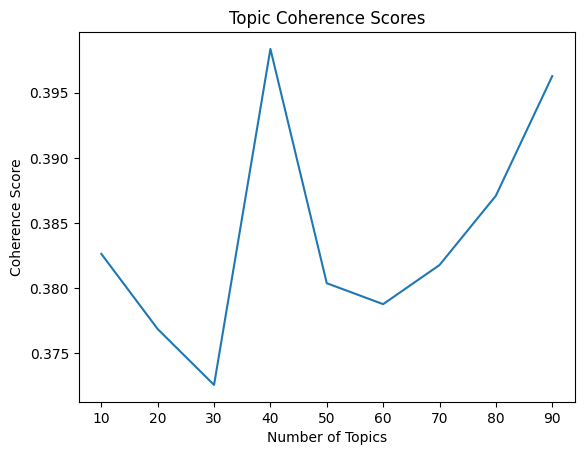

In [21]:
# Find optimal number of topics
scores = find_optimal_topics(
    dataset_raw_expanded['Room Description Expanded'],
    start=10,
    limit=100,
    step=10
)


Testing 100 topics...


/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/

Coherence score: 0.4091654602020167

Testing 110 topics...


/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/

Coherence score: 0.40704755926719793

Testing 120 topics...


...

Coherence score: 0.48318940273795424

Testing 230 topics...


/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/

Coherence score: 0.49039943731678537

Testing 240 topics...


/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/

Coherence score: 0.4924379182530552


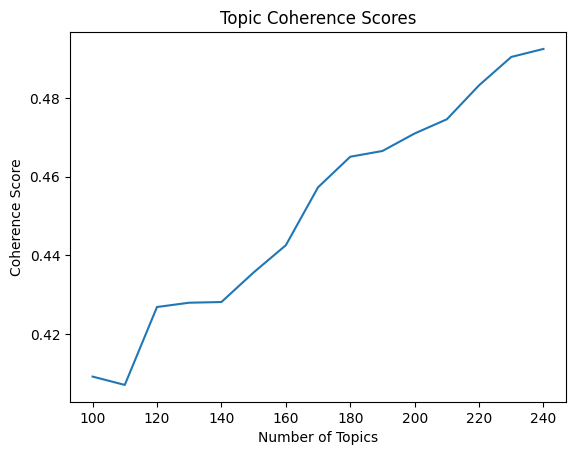

In [22]:
# Find optimal number of topics
scores_v2 = find_optimal_topics(
    dataset_raw_expanded['Room Description Expanded'],
    start=100,
    limit=250,
    step=10
)

## Guided LDA using attribute values

In [96]:
def create_guided_topics(attribute_lists):
    """
    Create seed topics from attribute lists
    
    attribute_lists = {
        'bed_types': bed_types_stripped_list,
        'room_amenities': room_amenities_stripped_list,
        'room_view': room_view_list,
        'meal_plan': meal_plan_list,
        # etc.
    }
    """
    seed_topics = {}
    for attr_name, values in attribute_lists.items():
        # Create seed words for each attribute value
        for value in values:
            # Split value into words
            words = value.lower().split()
            # Add related terms if needed
            seed_topics[f"{attr_name}_{value}"] = words
    
    return seed_topics

# Modified LDA with guided topics
def apply_guided_lda(descriptions, seed_topics, num_topics):
    """
    Apply LDA with seed topics from attributes
    """
    # Preprocess texts
    texts = [gensim.utils.simple_preprocess(desc, deacc=True) 
             for desc in descriptions]
    
    dictionary = corpora.Dictionary(texts)
    corpus = [dictionary.doc2bow(text) for text in texts]
    
    # Create vocabulary prior (eta)
    vocab_size = len(dictionary.token2id)
    eta = [0.001] * vocab_size  # base prior for all words
    
    # Boost words from seed topics
    for topic_words in seed_topics.values():
        for word in topic_words:
            if word in dictionary.token2id:
                word_id = dictionary.token2id[word]
                eta[word_id] = 200000.0  # boost these words
    
    # Train LDA with any number of topics
    model = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,  # can be any number
        eta=eta,  # vocabulary priors
        random_state=42,
        passes=10
    )
    
    return model, dictionary, corpus

In [103]:
# Create attribute dictionary
attribute_lists = {
    #'bed_types': bed_types_stripped_list,
    #'room_amenities': room_amenities_stripped_list,
    #'room_view': room_view_list,
    'meal_plan': meal_plan_list
}

# Get seed topics
seed_topics = create_guided_topics(attribute_lists)
"""
# Direct use of meal plan terms
meal_plan_words = []
for plan in meal_plan_list:
    meal_plan_words.extend(plan.lower().split())
meal_plan_words = list(set(meal_plan_words) - {'and', 'or', 'only'})  # remove stop words
"""

# Train guided model
guided_lda, dictionary, corpus = apply_guided_lda(
    dataset_raw_expanded['Room Description Expanded'],
    seed_topics, num_topics=15
)

In [64]:
#meal_plan_words

['continental',
 'dinner',
 'lunch',
 'half',
 'breakfast',
 'plan',
 'self',
 'catering',
 'board',
 'european',
 'buffet',
 'family',
 'room',
 'all',
 'inclusive',
 'modified',
 'full',
 'american']

In [104]:
import xlsxwriter

def format_topics(lda_model, num_topics=15, num_words=10):
    topics_df = pd.DataFrame()
    
    for idx in range(num_topics):
        words = []
        weights = []
        
        # Get topic words and their weights
        for word, weight in lda_model.show_topic(idx, num_words):
            words.append(word)
            weights.append(round(weight, 3))
        
        # Create readable format
        topic_dict = {
            'Topic': f'Topic {idx}',
            'Words': ', '.join(words),
            'Weights': ', '.join([f'{w:.3f}' for w in weights]),
            'Top 3 Words': ', '.join(words[:3]),
            'Interpretation': f'Topic about: {", ".join(words[:3])}'  # Simple interpretation
        }
        
        topics_df = pd.concat([topics_df, pd.DataFrame([topic_dict])], ignore_index=True)
    
    return topics_df

# Create readable topics
readable_topics = format_topics(guided_lda)
"""
# Save to Excel with formatting
with pd.ExcelWriter('guided_topic_analysis_15.xlsx', engine='xlsxwriter') as writer:
    readable_topics.to_excel(writer, index=False, sheet_name='Topics')
    
    # Auto-adjust column widths
    worksheet = writer.sheets['Topics']
    for idx, col in enumerate(readable_topics.columns):
        max_length = max(readable_topics[col].astype(str).apply(len).max(), len(col))
        worksheet.set_column(idx, idx, max_length + 2)
"""
print("Sample of readable format:")
print(readable_topics[['Topic', 'Top 3 Words', 'Interpretation']])

Sample of readable format:
       Topic           Top 3 Words                     Interpretation
0    Topic 0  room, and, breakfast  Topic about: room, and, breakfast
1    Topic 1    room, only, dinner    Topic about: room, only, dinner
2    Topic 2         room, and, or         Topic about: room, and, or
3    Topic 3  room, and, breakfast  Topic about: room, and, breakfast
4    Topic 4  room, and, breakfast  Topic about: room, and, breakfast
5    Topic 5  room, and, breakfast  Topic about: room, and, breakfast
6    Topic 6    room, only, dinner    Topic about: room, only, dinner
7    Topic 7    room, only, dinner    Topic about: room, only, dinner
8    Topic 8         room, and, or         Topic about: room, and, or
9    Topic 9         room, and, or         Topic about: room, and, or
10  Topic 10         room, and, or         Topic about: room, and, or
11  Topic 11  breakfast, room, and  Topic about: breakfast, room, and
12  Topic 12  room, and, breakfast  Topic about: room, and, bre

In [102]:
guided_lda.show_topics(num_topics=-1,
    num_words=15,
    formatted=True)

[(0,
  '0.050*"room" + 0.050*"and" + 0.050*"breakfast" + 0.050*"or" + 0.050*"full" + 0.050*"family" + 0.050*"all" + 0.050*"only" + 0.050*"board" + 0.050*"inclusive" + 0.050*"dinner" + 0.050*"self" + 0.050*"half" + 0.050*"buffet" + 0.050*"continental"'),
 (1,
  '0.050*"room" + 0.050*"and" + 0.050*"breakfast" + 0.050*"or" + 0.050*"full" + 0.050*"family" + 0.050*"only" + 0.050*"all" + 0.050*"board" + 0.050*"self" + 0.050*"buffet" + 0.050*"inclusive" + 0.050*"american" + 0.050*"dinner" + 0.050*"half"'),
 (2,
  '0.050*"room" + 0.050*"and" + 0.050*"breakfast" + 0.050*"or" + 0.050*"only" + 0.050*"family" + 0.050*"full" + 0.050*"board" + 0.050*"all" + 0.050*"buffet" + 0.050*"dinner" + 0.050*"inclusive" + 0.050*"half" + 0.050*"american" + 0.050*"self"'),
 (3,
  '0.050*"room" + 0.050*"and" + 0.050*"breakfast" + 0.050*"full" + 0.050*"or" + 0.050*"only" + 0.050*"buffet" + 0.050*"all" + 0.050*"family" + 0.050*"self" + 0.050*"inclusive" + 0.050*"continental" + 0.050*"dinner" + 0.050*"american" + 0.0

## Semantic (Sentence Transformer Embeddings) Clustering ##

In [106]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def semantic_clustering(descriptions, meal_plans, n_clusters=20):
    """
    Cluster descriptions based on semantic similarity to meal plans
    """
    # Load model
    model = SentenceTransformer('all-MiniLM-L6-v2')
    
    # Get embeddings
    desc_embeddings = model.encode(descriptions)
    plan_embeddings = model.encode(meal_plans)
    
    # Create clusters
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(desc_embeddings)
    
    # Analyze clusters
    cluster_analysis = []
    for i in range(n_clusters):
        # Get descriptions in this cluster
        cluster_mask = clusters == i
        cluster_embeddings = desc_embeddings[cluster_mask]
        cluster_descriptions = descriptions[cluster_mask]
        
        # Find closest meal plan
        similarities = cosine_similarity(
            cluster_embeddings.mean(axis=0).reshape(1, -1), 
            plan_embeddings
        )
        closest_plan = meal_plans[similarities.argmax()]
        
        cluster_analysis.append({
            'cluster_id': i,
            'size': sum(cluster_mask),
            'closest_meal_plan': closest_plan,
            'similarity_score': similarities.max(),
            'sample_descriptions': cluster_descriptions[:5].tolist()
        })
    
    return pd.DataFrame(cluster_analysis)

# Use the function
results = semantic_clustering(
    np.array(dataset_raw_expanded['Room Description Expanded']),
    np.array(meal_plan_list)
)

# Print results
print("\nCluster Analysis:")
print(results[['cluster_id', 'size', 'closest_meal_plan', 'similarity_score']].sort_values('size', ascending=False))


Cluster Analysis:
    cluster_id  size       closest_meal_plan  similarity_score
4            4  2752   Room Only or European          0.412960
9            9  2565   Room Only or European          0.455237
13          13  2462   Room Only or European          0.424107
7            7  2127   Room Only or European          0.427280
17          17  2086   Room Only or European          0.422515
1            1  2070   Room Only or European          0.430730
0            0  2039   Room Only or European          0.393312
2            2  1922   Room Only or European          0.408449
19          19  1824     Breakfast and Lunch          0.457426
16          16  1725   Room Only or European          0.575032
6            6  1502   Room Only or European          0.386956
3            3  1474     Breakfast and Lunch          0.643701
12          12  1237   Room Only or European          0.377555
11          11  1151   Room Only or European          0.345540
14          14   938             Fam

In [107]:
from sklearn.cluster import DBSCAN, OPTICS, AgglomerativeClustering
from hdbscan import HDBSCAN

def advanced_semantic_clustering(descriptions, meal_plans, method='hdbscan'):
    """
    Advanced clustering methods for semantic embeddings
    """
    # Get embeddings
    model = SentenceTransformer('all-MiniLM-L6-v2')
    desc_embeddings = model.encode(descriptions)
    plan_embeddings = model.encode(meal_plans)
    
    # Choose clustering method
    if method == 'hdbscan':
        # Better for finding natural clusters, handles noise
        clusterer = HDBSCAN(
            min_cluster_size=5,
            min_samples=3,
            metric='euclidean',
            cluster_selection_method='eom'  # Excess of Mass
        )
    
    elif method == 'dbscan':
        # Density-based clustering
        clusterer = DBSCAN(
            eps=0.3,
            min_samples=5,
            metric='euclidean'
        )
    
    elif method == 'optics':
        # Improved DBSCAN, better with varying densities
        clusterer = OPTICS(
            min_samples=5,
            metric='euclidean'
        )
    
    elif method == 'hierarchical':
        # Hierarchical clustering
        clusterer = AgglomerativeClustering(
            n_clusters=None,  # Don't specify number
            distance_threshold=0.3,
            linkage='ward'
        )
    
    # Fit and predict
    clusters = clusterer.fit_predict(desc_embeddings)
    
    # Analyze clusters (including noise points for HDBSCAN/DBSCAN)
    cluster_analysis = []
    unique_clusters = np.unique(clusters)
    
    for cluster_id in unique_clusters:
        cluster_mask = clusters == cluster_id
        cluster_embeddings = desc_embeddings[cluster_mask]
        cluster_descriptions = descriptions[cluster_mask]
        
        if cluster_id != -1:  # Not noise
            similarities = cosine_similarity(
                cluster_embeddings.mean(axis=0).reshape(1, -1), 
                plan_embeddings
            )
            closest_plan = meal_plans[similarities.argmax()]
            similarity_score = similarities.max()
        else:
            closest_plan = "Noise"
            similarity_score = 0
            
        cluster_analysis.append({
            'cluster_id': cluster_id,
            'size': sum(cluster_mask),
            'closest_meal_plan': closest_plan,
            'similarity_score': similarity_score,
            'sample_descriptions': cluster_descriptions[:5].tolist()
        })
    
    return pd.DataFrame(cluster_analysis)

# Try different methods
methods = ['hdbscan', 'dbscan', 'optics', 'hierarchical']
results = {}

for method in methods:
    print(f"\nTrying {method.upper()} clustering:")
    results[method] = advanced_semantic_clustering(
        np.array(dataset_raw_expanded['Room Description Expanded']),
        np.array(meal_plan_list),
        method=method
    )


Trying HDBSCAN clustering:


/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/karthik1705/Desktop/Projects/Sabre 2025/LLM Attribute Normalization/distiLLM/llm/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Trying DBSCAN clustering:

Trying OPTICS clustering:

Trying HIERARCHICAL clustering:


In [109]:
results['hdbscan']

,cluster_id,size,closest_meal_plan,similarity_score,sample_descriptions
0,-1,16344,Noise,0.000000,[STAY PARK FLY ACCESSIBLE 1BR KING TUB|INCLUDE...
1,0,8,Self Catering,0.323767,[DRIVE TO DELIGHT YOURSELF|PREMIUM FAMILY ROOM...
2,1,5,Family Plan,0.171568,"[JOURNEY TO RESILIENCE|EXECUTIVE SUITE, JOURNE..."
3,2,6,Self Catering,0.239275,[AAA HOT DEALS|AMBASSADOR 2BR FAMILY SUITE-OCE...
4,3,6,All Inclusive,0.276357,[EXPERIENCES ATTRACTION|OMAHA ZOO FOR YOU PACK...
...,...,...,...,...,...
1150,1149,27,Room Only or European,0.403071,"[REGULAR RATE|FLEXIBLE RATE, PRIMARY KING ROOM..."
1151,1150,9,Room Only or European,0.402014,"[REGULAR RATE|FLEXIBLE RATE, CORNER KING ROOM,..."
1152,1151,11,Room Only or European,0.338372,"[REGULAR RATE|FLEXIBLE RATE, FAMILY SUITE, JUN..."
1153,1152,48,Room Only or European,0.352163,"[REGULAR RATE|FLEXIBLE RATE, 1 BEDROOM LARGER ..."



Clustering Evaluation:
              num_clusters  noise_points  avg_cluster_size  avg_similarity  \
hdbscan             1154.0           1.0         12.905546        0.340999   
dbscan               267.0           1.0         14.235955        0.349237   
optics              1038.0           1.0          8.185934        0.338535   
hierarchical       24885.0           0.0          1.255254        0.325325   

              unique_meal_plans  meal_plan_coverage  large_clusters  \
hdbscan                    16.0            1.000000           398.0   
dbscan                     13.0            0.800000            70.0   
optics                     15.0            0.933333           197.0   
hierarchical               15.0            1.000000             8.0   

              high_similarity_clusters  
hdbscan                            1.0  
dbscan                             0.0  
optics                             1.0  
hierarchical                       3.0  


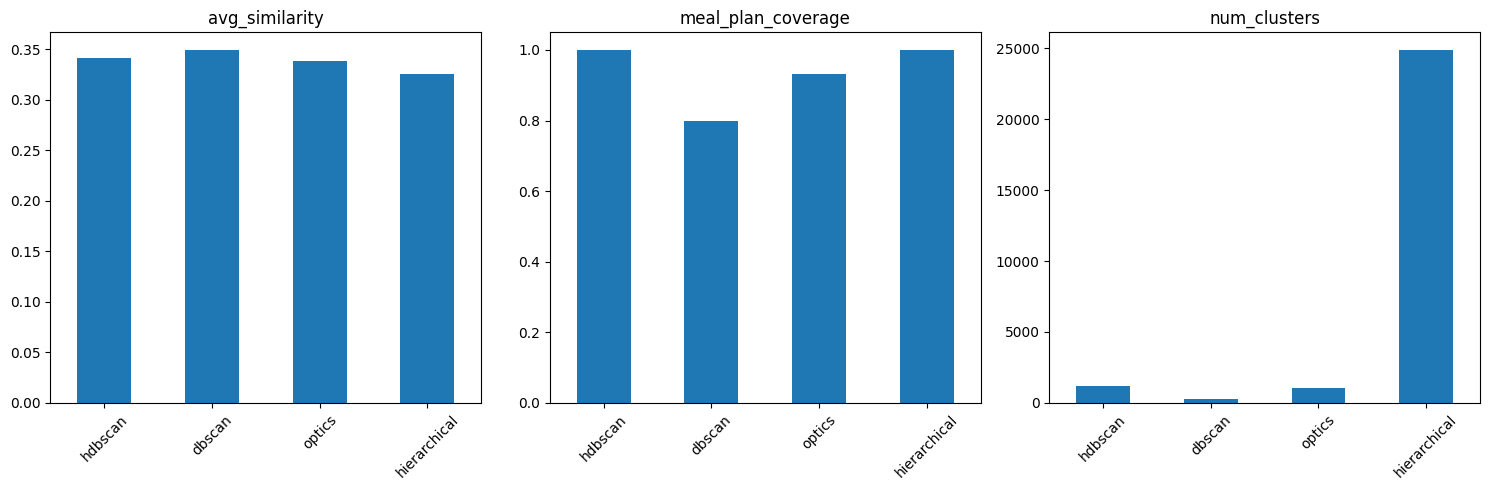

In [110]:
def evaluate_clustering_results(results_dict, meal_plans):
    evaluation = {}
    
    for method, df in results_dict.items():
        # 1. Basic Statistics
        stats = {
            'num_clusters': len(df[df['cluster_id'] != -1]),  # Exclude noise
            'noise_points': len(df[df['cluster_id'] == -1]) if -1 in df['cluster_id'].values else 0,
            'avg_cluster_size': df[df['cluster_id'] != -1]['size'].mean(),
            'avg_similarity': df[df['cluster_id'] != -1]['similarity_score'].mean(),
            'unique_meal_plans': df['closest_meal_plan'].nunique()
        }
        
        # 2. Distribution Analysis
        meal_plan_dist = df[df['cluster_id'] != -1]['closest_meal_plan'].value_counts()
        coverage = len(meal_plan_dist) / len(meal_plans)
        
        # 3. Cluster Quality
        large_clusters = df[df['size'] > 10]['size'].count()  # Clusters with >10 points
        high_similarity = df[df['similarity_score'] > 0.7]['cluster_id'].nunique()
        
        evaluation[method] = {
            **stats,
            'meal_plan_coverage': coverage,
            'large_clusters': large_clusters,
            'high_similarity_clusters': high_similarity
        }
    
    return pd.DataFrame(evaluation).T

# Evaluate all methods
eval_df = evaluate_clustering_results(results, meal_plan_list)
print("\nClustering Evaluation:")
print(eval_df)

# Visualize key metrics
import matplotlib.pyplot as plt

def plot_evaluation(eval_df):
    metrics = ['avg_similarity', 'meal_plan_coverage', 'num_clusters']
    fig, axes = plt.subplots(1, len(metrics), figsize=(15, 5))
    
    for i, metric in enumerate(metrics):
        eval_df[metric].plot(kind='bar', ax=axes[i])
        axes[i].set_title(metric)
        axes[i].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

plot_evaluation(eval_df)

In [116]:
results['hdbscan'].to_csv('mealplan_minilm_hdbscan.csv')

In [118]:
results['hierarchical'].to_csv('mealplan_minilm_hierarchical.csv')